# Proyecto - Análisis de comportamiento de usuario y Test A/A/B
Por Inti Alberto Romero González

## Introducción
Trabajamos en una startup de productos alimenticios. El objetivo es investigar el comportamiento del usuario en la aplicación móvil y analizar los resultados de un test A/A/B donde se cambió la fuente de la aplicación.

# Verificación de Dataset descargado

In [ ]:
import os
import requests
import pandas as pd

def descargar_dataset():
    """
    Descarga el dataset de logs_exp_us.csv desde una URL pública 
    y lo guarda en la carpeta 'data', si no existe.
    """
    url = "https://code.s3.yandex.net/datasets/logs_exp_us.csv"  # Reemplaza con la URL real
    archivo = 'data/logs_exp_us.csv'

    # Verifica si el archivo ya existe
    if os.path.exists(archivo):
        print(f"✅ El archivo {archivo} ya existe")

        # Preguntar si quieren descargarlo de nuevo
        respuesta = input("¿Deseas descargarlo de nuevo? (s/n): ").strip().lower()
        if respuesta not in ['s', 'si', 'sí', 'y', 'yes']:
            print("📊 Usando el archivo existente.")
            return
        
    # Descargar el archivo
    print(f"📥 Descargando el dataset desde {url}...")
    try:
        response = requests.get(url)
        response.raise_for_status()  # Verifica que la descarga fue exitosa

        # Asegura que la carpeta 'data' exista
        os.makedirs('data', exist_ok=True)

        # Guarda el archivo descargado
        with open(archivo, 'wb') as f:
            f.write(response.content)

        # Verifica que se descargó correctamente        if os.path.exists(archivo):
            file_size = os.path.getsize(archivo) / (1024*1024)  # Tamaño en MB
            print(f"✅ Dataset descargado y guardado en {archivo} ({file_size:.2f} MB)")
        
        return True
    
    except requests.exceptions.RequestException as e:
        print(f"❌ ERROR al descargar el dataset: {e}")
        return False
    except Exception as e:
        print(f"❌ ERROR inesperado: {e}")
        return False
    
# Ejecutar la función de descarga
if descargar_dataset():
        print("¡Listo para comenzar el análisis!")

✅ El archivo data/logs_exp_us.csv ya existe
📥 Descargando el dataset desde https://code.s3.yandex.net/datasets/logs_exp_us.csv...
✅ Dataset descargado y guardado en data/logs_exp_us.csv (12.62 MB)
¡Listo para comenzar el análisis!


## Preparación de datos

In [2]:
# Importar las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import datetime as dt

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [3]:
try:
    logs = pd.read_csv('./data/logs_exp_us.csv', sep='\t') # A veces estos logs vienen separados por tabuladores
    print("Datos cargados exitosamente.")
except:
    try:
        logs = pd.read_csv('./data/logs_exp_us.csv') # Intento estándar por comas
        print("Datos cargados exitosamente (separador estándar).")
    except:
        print("Error al cargar los datos. Verifica la ruta.")

# Mostrar las primeras filas
print(logs.head())

Datos cargados exitosamente.
                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248


In [4]:
# Renombrar columnas para facilitar el trabajo
logs.columns = ['event_name', 'user_id', 'timestamp', 'group']

# Verificar información general y nulos
print("--- Información General ---")
logs.info()
print("\n--- Valores Nulos ---")
print(logs.isna().sum())

# Verificar duplicados
print(f"\nDuplicados: {logs.duplicated().sum()}")

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   event_name  244126 non-null  object
 1   user_id     244126 non-null  int64 
 2   timestamp   244126 non-null  int64 
 3   group       244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB

--- Valores Nulos ---
event_name    0
user_id       0
timestamp     0
group         0
dtype: int64

Duplicados: 413


In [5]:
# Eliminamos duplicados
logs = logs.drop_duplicates().reset_index(drop=True)

# Convertir timestamp a datetime
logs['datetime'] = pd.to_datetime(logs['timestamp'], unit='s')

# Crear columna de fecha para el análisis diario y convertir a datetime
logs['date'] = logs['datetime'].dt.date
logs['date'] = pd.to_datetime(logs['date'])

print("--- Datos después del preprocesamiento ---")
print(logs.head())
print()
logs.info()
print(f"\nDuplicados: {logs.duplicated().sum()}")

--- Datos después del preprocesamiento ---
                event_name              user_id   timestamp  group  \
0         MainScreenAppear  4575588528974610257  1564029816    246   
1         MainScreenAppear  7416695313311560658  1564053102    246   
2  PaymentScreenSuccessful  3518123091307005509  1564054127    248   
3         CartScreenAppear  3518123091307005509  1564054127    248   
4  PaymentScreenSuccessful  6217807653094995999  1564055322    248   

             datetime       date  
0 2019-07-25 04:43:36 2019-07-25  
1 2019-07-25 11:11:42 2019-07-25  
2 2019-07-25 11:28:47 2019-07-25  
3 2019-07-25 11:28:47 2019-07-25  
4 2019-07-25 11:48:42 2019-07-25  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event_name  243713 non-null  object        
 1   user_id     243713 non-null  int64         
 2   timestamp   24

## Estudiar y comprobar datos

En esta sección analizaremos:
1.  **Volumen de datos:** Cantidad total de eventos y usuarios.
2.  **Promedio de eventos:** Cuántas acciones realiza un usuario promedio.
3.  **Periodo de tiempo:** Fechas mínima y máxima.
4.  **Calidad de los datos temporales:** Usaremos un histograma para identificar desde qué fecha los datos son completos y descartaremos el periodo anterior que podría sesgar el análisis.

In [6]:
# Cantidad de eventos y usuarios
total_events = logs.shape[0]
total_users = logs['user_id'].nunique()

print(f"Total de eventos: {total_events}")
print(f"Total de usuarios: {total_users}")

# Promedio de eventos por usuario
avg_events = total_events / total_users
print(f"Promedio de eventos por usuario: {avg_events:.2f}")

# Periodo de tiempo
min_date = logs['datetime'].min()
max_date = logs['datetime'].max()

print(f"Fecha mínima: {min_date}")
print(f"Fecha máxima: {max_date}")
print(f"Total de días: {(max_date - min_date).days}")

Total de eventos: 243713
Total de usuarios: 7551
Promedio de eventos por usuario: 32.28
Fecha mínima: 2019-07-25 04:43:36
Fecha máxima: 2019-08-07 21:15:17
Total de días: 13


### Total de eventos y usuarios únicos en cada grupo

In [7]:
# Calculamos métricas clave agrupadas por el experimento
# Agrupamos por 'group' y calculamos el total de eventos y usuarios únicos en cada grupo
metrics_by_group = logs.groupby('group').agg(
    total_events=('user_id', 'count'),
    total_users=('user_id', 'nunique')
).reset_index()

# Calculamos el promedio de eventos por usuario en cada grupo
metrics_by_group['avg_events_per_user'] = (
    metrics_by_group['total_events'] / metrics_by_group['total_users']
)

print("--- Comparativa Inicial por Grupos ---")
print(metrics_by_group)

--- Comparativa Inicial por Grupos ---
   group  total_events  total_users  avg_events_per_user
0    246         80181         2489            32.214142
1    247         77950         2520            30.932540
2    248         85582         2542            33.667191


### Promedio de Eventos por Usuario según el Grupo

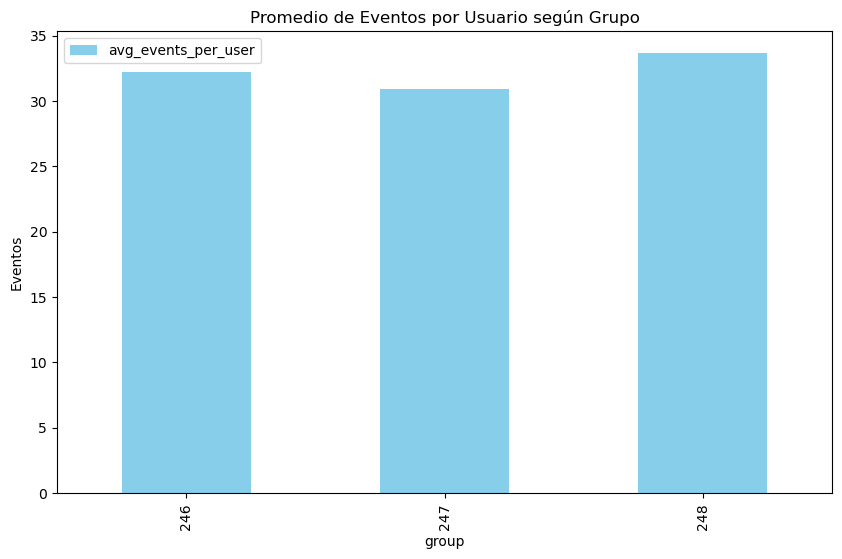

In [8]:
import matplotlib.pyplot as plt

metrics_by_group.plot(kind='bar', x='group', y='avg_events_per_user', color='skyblue')
plt.title('Promedio de Eventos por Usuario según Grupo')
plt.ylabel('Eventos')
plt.show()

### Distribución de eventos por fecha y hora

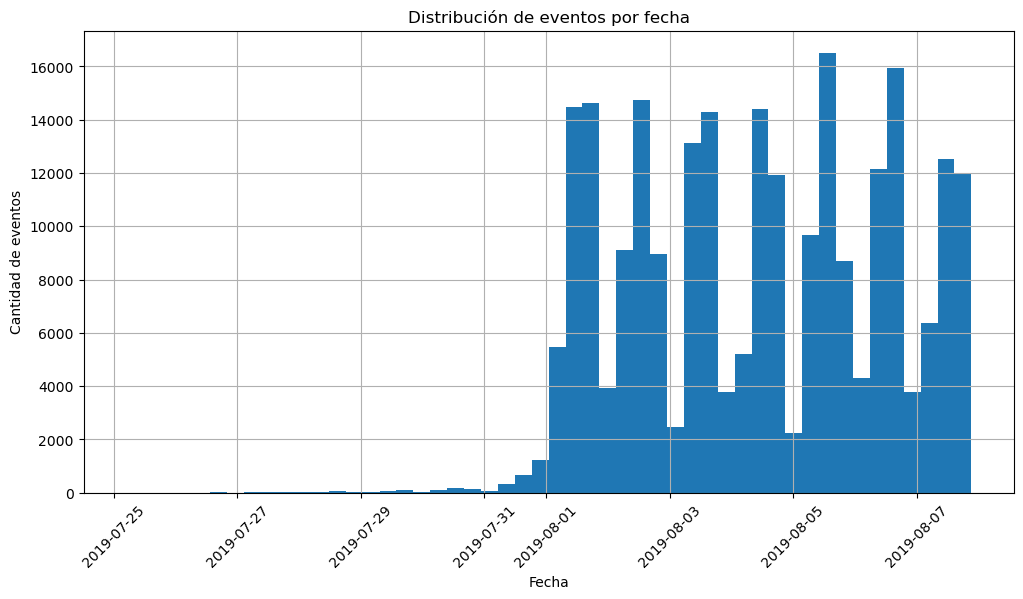


Conteo de eventos por día (Primeros 10 días ordenados):
    date_only  total_eventos
0  2019-07-25              9
1  2019-07-26             31
2  2019-07-27             55
3  2019-07-28            105
4  2019-07-29            184
5  2019-07-30            412
6  2019-07-31           2030
7  2019-08-01          36141
8  2019-08-02          35554
9  2019-08-03          33282


In [9]:
# Histograma de distribución de eventos por fecha y hora
plt.figure(figsize=(12, 6))
logs['datetime'].hist(bins=50)
plt.title('Distribución de eventos por fecha')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.show()

# Para ver con más detalle, veamos solo las fechas únicas ordenadas
logs['date_only'] = logs['date'].dt.date
eventos_por_dia = logs.groupby('date_only').size().reset_index(name='total_eventos')
print("\nConteo de eventos por día (Primeros 10 días ordenados):")
print(eventos_por_dia.head(10))

### Distribución de eventos por día

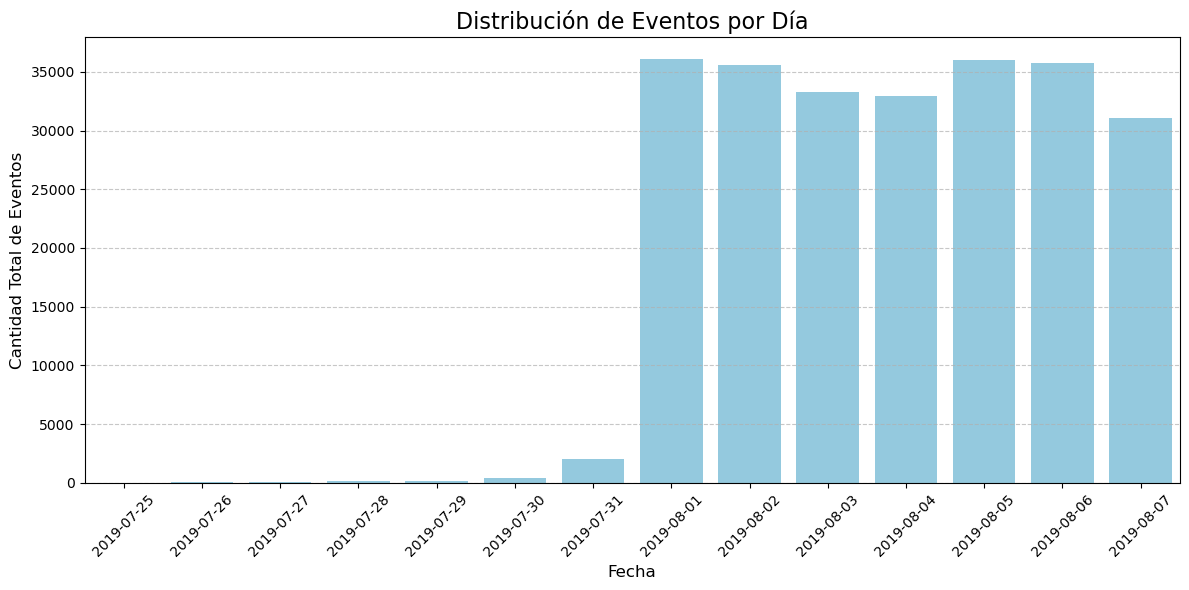

In [10]:
plt.figure(figsize=(12, 6))

# Crear una gráfica de barras
sns.barplot(data=eventos_por_dia, x='date_only', y='total_eventos', color='skyblue')
plt.title('Distribución de Eventos por Día', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad Total de Eventos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Mostrar la gráfica
plt.tight_layout() # Ajusta los elementos para que nada se corte
plt.show()

### Conclusiones parte 1
Al graficar los eventos diarios, notamos algo extraño. Los primeros días casi no hay actividad, y de repente el primero de agosto el tráfico explota y se mantiene alto. Esto sugiere que los datos de julio quizás son pruebas y no reflejan el uso real de la aplicación

### ¿Cuánto representa los datos de julio del total?

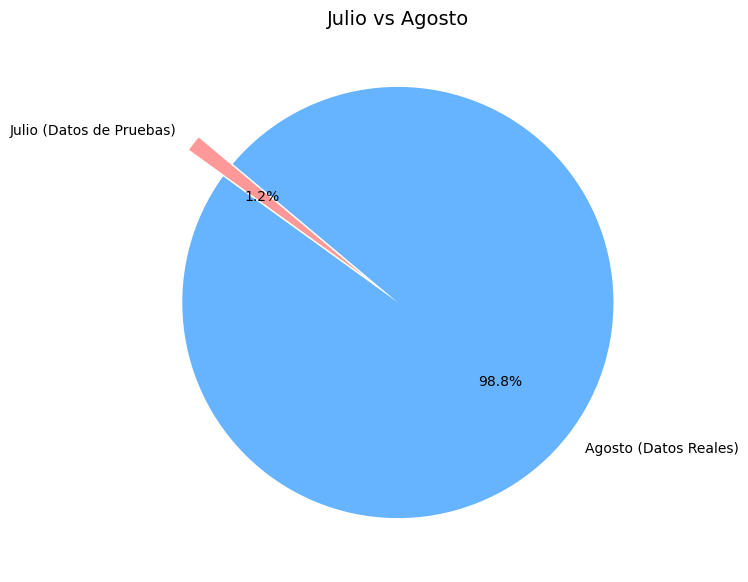

In [11]:
# Contamos cuántos eventos caen en cada periodo
eventos_julio = logs[logs['date'] < '2019-08-01'].shape[0]
eventos_agosto = logs[logs['date'] >= '2019-08-01'].shape[0]

# Preparamos los datos para el pastel
cantidades = [eventos_julio, eventos_agosto]
etiquetas = ['Julio (Datos de Pruebas)', 'Agosto (Datos Reales)']
colores = ['#ff9999', '#66b3ff']

# Generamos el gráfico
plt.figure(figsize=(7, 7))
plt.pie(cantidades, labels=etiquetas, autopct='%1.1f%%', startangle=140, colors=colores, explode=(0.2, 0))
plt.title('Julio vs Agosto', fontsize=14)
plt.show()

A continuación, creamos un nuevo DataFrame solo con los datos de Agosto en adelante

### Filtramos datos

In [12]:
# Crear nuevo DataFrame limpio
logs_agosto = logs[logs['date'] >= '2019-08-01'].copy()

# Guardamos el archivo en la carpeta 'data' de tu proyecto
logs_agosto.to_csv('data/logs_exp_us_cleaned.csv', index=False)

# Verificación de limpieza
print("--- Resultados de la Limpieza ---")
print(f"Filas originales (logs): {len(logs)}")
print(f"Filas después de filtrar (logs_agosto): {len(logs_agosto)}")
print(f"Filas eliminadas (Julio): {len(logs) - len(logs_agosto)}")

--- Resultados de la Limpieza ---
Filas originales (logs): 243713
Filas después de filtrar (logs_agosto): 240887
Filas eliminadas (Julio): 2826


## Análisis de Embudo

### Análisis de Embudo General

In [13]:
# Contamos los usuarios únicos
n_usuarios_agosto = logs_agosto['user_id'].nunique()

print(f"Total de usuarios únicos (Agosto): {n_usuarios_agosto}")

Total de usuarios únicos (Agosto): 7534


In [14]:
# 1. Agrupar por evento y contar usuarios únicos (usando user_id)
funnel = logs_agosto.groupby('event_name')['user_id'].nunique().reset_index()
funnel.columns = ['Evento', 'Usuarios']

# 2. Ordenar de mayor a menor para ver la caída lógica
funnel = funnel.sort_values(by='Usuarios', ascending=False).reset_index(drop=True)

# 3. Calcular porcentajes para entender la retención
# % respecto al paso inicial (Retención total desde el inicio)
funnel['% del Total'] = (funnel['Usuarios'] / funnel['Usuarios'].max()) * 100

# % respecto al paso inmediato anterior
funnel['% Paso Anterior'] = funnel['Usuarios'].pct_change() + 1
funnel['% Paso Anterior'] = funnel['% Paso Anterior'].fillna(1) * 100 

# Imprimir resultado
print("--- AMBUDO DE EVENTOS ---")
print(funnel[['Evento', 'Usuarios', '% del Total', '% Paso Anterior']].round(1))

--- AMBUDO DE EVENTOS ---
                    Evento  Usuarios  % del Total  % Paso Anterior
0         MainScreenAppear      7419        100.0            100.0
1       OffersScreenAppear      4593         61.9             61.9
2         CartScreenAppear      3734         50.3             81.3
3  PaymentScreenSuccessful      3539         47.7             94.8
4                 Tutorial       840         11.3             23.7


In [22]:
import plotly.graph_objects as go

# Filtramos el Tutorial para quedarnos con el flujo de compra
funnel_real = funnel[funnel['Evento'] != 'Tutorial'].copy()

# Definimos el mapeo de nombres de eventos a etiquetas más amigables
traduccion_eventos = {
    'MainScreenAppear': 'Inicio (Pantalla Principal)',
    'OffersScreenAppear': 'Catálogo de Ofertas',
    'CartScreenAppear': 'Carrito de Compras',
    'PaymentScreenSuccessful': 'Pago Exitoso'
}

# Creamos un gráfico de embudo interactivo
fig = go.Figure(go.Funnel(
    y = funnel_real['Evento'].map(traduccion_eventos),
    x = funnel_real['Usuarios'],
    textposition = "inside",
    textinfo = "value+percent initial", # Muestra cantidad y % respecto al inicio
    opacity = 0.65, 
    marker = {"color": ["deepskyblue", "lightsalmon", "tan", "teal", "silver"],
              "line": {"width": [4, 2, 2, 3, 1, 1], "color": ["wheat", "wheat", "blue", "wheat"]}},
    connector = {"line": {"color": "royalblue", "dash": "dot", "width": 3}}
    ))

fig.update_layout(
    title_text= 'Embudo de Conversión (Flujo Principal)',
    yaxis_title='Etapa del proceso',
    template='plotly_white'
    )

fig.show()

#### Conclusión parte 2
**En promedio, el 47.7% de todos los usuarios llegan a pagar.**<br>
Bien, ahora ¿Cuál es el promedio de eventos por cada grupo?

### Comparativa de Embudo por Grupos A/B

In [16]:
import plotly.graph_objects as go
import pandas as pd

# 1. Crear la estructura del embudo agrupada por evento y grupo
# Contamos usuarios únicos ('nunique')
funnel_by_group = logs_agosto.groupby(['event_name', 'group'])['user_id'].nunique().reset_index()
funnel_by_group.columns = ['Event', 'Group', 'Users']

# 2. Ordenar los eventos lógicamente (según tu análisis previo)
# Esto es crucial para que el embudo tenga sentido
event_order = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

# Usamos una categoría ordenada para forzar el orden correcto
funnel_by_group['Event'] = pd.Categorical(funnel_by_group['Event'], categories=event_order, ordered=True)
funnel_by_group = funnel_by_group.dropna().sort_values(['Group', 'Event'])

print("--- Datos del Embudo Segmentado ---")
print(funnel_by_group.head(12)) # Verificamos los primeros registros

--- Datos del Embudo Segmentado ---
                      Event  Group  Users
3          MainScreenAppear    246   2450
6        OffersScreenAppear    246   1542
0          CartScreenAppear    246   1266
9   PaymentScreenSuccessful    246   1200
4          MainScreenAppear    247   2476
7        OffersScreenAppear    247   1520
1          CartScreenAppear    247   1238
10  PaymentScreenSuccessful    247   1158
5          MainScreenAppear    248   2493
8        OffersScreenAppear    248   1531
2          CartScreenAppear    248   1230
11  PaymentScreenSuccessful    248   1181


In [17]:
# 3. Crear el gráfico de embudo comparativo
fig = go.Figure()

# Definimos colores profesionales para diferenciar control y test
# Usaremos tonos grises/azules para control y un color llamativo para el test
colors = {246: '#A9A9A9',  # DarkGray (Control 1)
          247: '#87CEEB',  # SkyBlue (Control 2)
          248: '#FF7F50'}  # Coral (Test)

# Iteramos sobre cada grupo para añadirlo al gráfico
for group in funnel_by_group['Group'].unique():
    group_data = funnel_by_group[funnel_by_group['Group'] == group]
    
    fig.add_trace(go.Funnel(
        name=f'Grupo {group}',
        y=group_data['Event'],
        x=group_data['Users'],
        textinfo="value+percent initial", # Muestra el valor y % respecto al inicio
        marker={"color": colors[group]}   # Asigna el color definido
    ))

# 4. Configurar el diseño para portafolio
fig.update_layout(
    title='Comparativa de Conversión del Embudo por Grupo A/B',
    yaxis_title='Paso del Embudo',
    legend_title='Grupo del Experimento',
    template='plotly_white', # Fondo limpio
    margin=dict(l=150, r=20, t=80, b=20) # Ajuste de márgenes
)

fig.show()

#### Conclusión parte 3
Al segmentar el embudo por grupos experimentales, observamos que el **Grupo 248 (Control)** presenta la mayor tasa de conversión hacia el carrito con un **52%**, superando ligeramente al **Grupo 248 (Test)** que registra un 49%.

Sin embargo, es notable que al llegar al paso final **(PaymentScreenSuccessful)**, las diferencias se reducen drásticamente, con el Grupo 246 en **49%** y los grupos 247 y 248 empatados en **47%**. Esto sugiere que, aunque el Grupo 246 es más eficiente llevando gente al carrito, la eficacia final del proceso de pago es muy similar entre los tres grupos.

## Análisis de Test A/A/B
### ¿Cuántos usuarios hay en cada grupo?

In [18]:
# Conteo de usuarios por grupo
usuarios_por_grupo = logs_agosto.groupby('group')['user_id'].nunique()

print("--- Distribución de Usuarios por Grupo ---")
print(usuarios_por_grupo)

# Chequeo de usuarios duplicados entre grupos
# Obtenemos las listas de usuarios de cada grupo
grupos = logs_agosto['group'].unique()
usuarios_problematicos = []

# Iteramos para comparar todos contra todos
for g1 in grupos:
    for g2 in grupos:
        if g1 != g2:
            users_g1 = set(logs_agosto[logs_agosto['group'] == g1]['user_id'])
            users_g2 = set(logs_agosto[logs_agosto['group'] == g2]['user_id'])
            
            # Intersección: usuarios que están en ambos sets
            comunes = users_g1.intersection(users_g2)
            
            if len(comunes) > 0:
                print(f"\n¡ALERTA! Hay {len(comunes)} usuarios compartidos entre el grupo {g1} y {g2}.")
                usuarios_problematicos.extend(list(comunes))

if len(usuarios_problematicos) == 0:
    print("\n✅ Todo limpio: No hay usuarios mezclados entre grupos.")
else:
    print(f"\n⚠️ Total de usuarios únicos a eliminar (contaminados): {len(set(usuarios_problematicos))}")

--- Distribución de Usuarios por Grupo ---
group
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

✅ Todo limpio: No hay usuarios mezclados entre grupos.


Los grupos tienen tamaños muy similares ($2484$, $2513$, $2537$). La diferencia es mínima, lo que hace que la comparación sea justa.

#### Conclusión parte 4
Se observa una ligera discrepancia entre **el total de usuarios por grupo** y **los usuarios que inician el embudo en 'MainScreenAppear'**. Aproximadamente un **1%** de los usuarios de cada grupo no registra el evento inicial, lo cual sugiere un abandono prematuro antes de la carga de la pantalla principal.

### Test A/A

Antes de ver si el grupo B (el del cambio) funcionó mejor, haremos el Test A/A.

Vamos a comparar el Grupo 246 contra el Grupo 247. Como ambos son grupos de control (nadie vio cambios en ellos), estadísticamente deberían ser idénticos.

- Si encontramos diferencias significativas entre el 246 y el 247, tenemos un problema (el tráfico se dividió mal).

- Si no hay diferencias, tenemos luz verde para confiar en los resultados del Grupo B.

Usaremos la prueba estadística Z-test para proporciones.

In [19]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

def verificar_hipotesis(grupo1, grupo2, evento, alpha=0.05):
    """
    Compara si hay una diferencia estadísticamente significativa entre dos grupos
    para un evento específico.
    """
    # 1. Obtener los totales de usuarios en cada grupo
    n_users_1 = logs_agosto[logs_agosto['group'] == grupo1]['user_id'].nunique()
    n_users_2 = logs_agosto[logs_agosto['group'] == grupo2]['user_id'].nunique()
    
    # 2. Obtener cuántos de esos usuarios realizaron el evento
    successes_1 = logs_agosto[(logs_agosto['group'] == grupo1) & (logs_agosto['event_name'] == evento)]['user_id'].nunique()
    successes_2 = logs_agosto[(logs_agosto['group'] == grupo2) & (logs_agosto['event_name'] == evento)]['user_id'].nunique()
    
    # 3. Preparar datos para el test
    successes = np.array([successes_1, successes_2])
    nobs = np.array([n_users_1, n_users_2])
    
    # 4. Calcular p-value
    stat, p_value = proportions_ztest(successes, nobs)
    
    print(f"--- {evento} ---")
    print(f"Grupo {grupo1}: {successes_1}/{n_users_1} ({successes_1/n_users_1:.2%})")
    print(f"Grupo {grupo2}: {successes_2}/{n_users_2} ({successes_2/n_users_2:.2%})")
    print(f"p-value: {p_value:.5f}")
    
    if p_value < alpha:
        print("🔴 RECHAZAMOS la hipótesis nula: Hay una diferencia significativa (Los grupos son distintos).")
    else:
        print("✅ NO RECHAZAMOS la hipótesis nula: No hay diferencia significativa (Los grupos son iguales).")
    print("-" * 50)

# --- EJECUCIÓN DEL TEST A/A ---
# Vamos a probar con el evento más importante: el Pago.

verificar_hipotesis(246, 247, 'PaymentScreenSuccessful')

--- PaymentScreenSuccessful ---
Grupo 246: 1200/2484 (48.31%)
Grupo 247: 1158/2513 (46.08%)
p-value: 0.11457
✅ NO RECHAZAMOS la hipótesis nula: No hay diferencia significativa (Los grupos son iguales).
--------------------------------------------------


La diferencia entre tus grupos de control es puro azar. El sistema de división de usuarios funciona perfectamente.

### Test A/B

In [20]:
# --- COMPARACIÓN FINAL: Control Combinado (246+247) vs Test (248) ---

def test_ab_completo(grupo_control_lista, grupo_test, dataframe):
    # Lista de eventos ordenados por el funnel lógico
    eventos = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
    
    print(f"--- TEST A/B: Control {grupo_control_lista} vs Grupo {grupo_test} ---\n")
    
    for evento in eventos:
        # 1. Datos del Grupo Control (Sumamos usuarios de 246 y 247)
        mask_control = dataframe['group'].isin(grupo_control_lista)
        n_users_control = dataframe[mask_control]['user_id'].nunique()
        successes_control = dataframe[mask_control & (dataframe['event_name'] == evento)]['user_id'].nunique()
        
        # 2. Datos del Grupo Test (248)
        mask_test = dataframe['group'] == grupo_test
        n_users_test = dataframe[mask_test]['user_id'].nunique()
        successes_test = dataframe[mask_test & (dataframe['event_name'] == evento)]['user_id'].nunique()
        
        # 3. Z-Test
        successes = np.array([successes_control, successes_test])
        nobs = np.array([n_users_control, n_users_test])
        
        stat, p_value = proportions_ztest(successes, nobs)
        
        # 4. Reporte
        print(f"Evento: {evento}")
        print(f"  Control: {successes_control}/{n_users_control} ({successes_control/n_users_control:.2%})")
        print(f"  Test:    {successes_test}/{n_users_test} ({successes_test/n_users_test:.2%})")
        print(f"  p-value: {p_value:.5f}")
        
        if p_value < 0.05:
            print("  🔴 RESULTADO: Diferencia Significativa (¡Algo cambió!)")
        else:
            print("  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)")
        print("-" * 40)

# Ejecutamos la función comparando (246 y 247) vs 248
test_ab_completo([246, 247], 248, logs_agosto)

--- TEST A/B: Control [246, 247] vs Grupo 248 ---



Evento: MainScreenAppear
  Control: 4926/4997 (98.58%)
  Test:    2493/2537 (98.27%)
  p-value: 0.29425
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------
Evento: OffersScreenAppear
  Control: 3062/4997 (61.28%)
  Test:    1531/2537 (60.35%)
  p-value: 0.43426
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------
Evento: CartScreenAppear
  Control: 2504/4997 (50.11%)
  Test:    1230/2537 (48.48%)
  p-value: 0.18176
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------
Evento: PaymentScreenSuccessful
  Control: 2358/4997 (47.19%)
  Test:    1181/2537 (46.55%)
  p-value: 0.60043
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------


In [21]:
# Comparación Grupo A1 (246) vs Grupo B (248)
print("--- COMPARACIÓN: Control A1 (246) vs Test (248) ---")
test_ab_completo([246], 248, logs_agosto)

print("\n" + "="*50 + "\n")

# Comparación Grupo A2 (247) vs Grupo B (248)
print("--- COMPARACIÓN: Control A2 (247) vs Test (248) ---")
test_ab_completo([247], 248, logs_agosto)

--- COMPARACIÓN: Control A1 (246) vs Test (248) ---
--- TEST A/B: Control [246] vs Grupo 248 ---

Evento: MainScreenAppear
  Control: 2450/2484 (98.63%)
  Test:    2493/2537 (98.27%)
  p-value: 0.29497
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------
Evento: OffersScreenAppear
  Control: 1542/2484 (62.08%)
  Test:    1531/2537 (60.35%)
  p-value: 0.20836
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------
Evento: CartScreenAppear
  Control: 1266/2484 (50.97%)
  Test:    1230/2537 (48.48%)
  p-value: 0.07843
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------
Evento: PaymentScreenSuccessful
  Control: 1200/2484 (48.31%)
  Test:    1181/2537 (46.55%)
  p-value: 0.21226
  ✅ RESULTADO: Sin cambios significativos (Todo sigue igual)
----------------------------------------


--- COMPARACIÓN: Control A2 (247) vs Test (248) ---
--- TEST A/B: C

### Conclusiones del Experimento A/B
1. **Calidad de los Datos:** Se detectó que los datos de julio eran inestables (fase de prueba). 
Se procedió a analizar únicamente el periodo del **1 al 7 de agosto**, donde la captura de datos fue constante (~35k eventos diarios).
2. **Comportamiento del Usuario (Funnel):** El embudo de ventas es saludable.
    - La mayor pérdida de usuarios ocurre al inicio (**38%** abandona antes de ver ofertas).
    - La conversión final es excelente: cerca del **48%** de los usuarios que abren la app terminan realizando una compra exitosa.
4. **Resultados del Test A/A/B:**
    - Los grupos de control (246 y 247) (246 y 248) (247 y 248) no mostraron diferencias entre sí, validando la precisión del sistema de división de usuarios.
    - Al comparar el **Grupo de Control Combinado** contra el **Grupo de Test (Nuevas Fuentes)**, el valor p ($p\text{-value}$) fue superior a 0.05 en todos los eventos.

**Veredicto:** No hay evidencia estadística para afirmar que el cambio de fuentes impacte el comportamiento del usuario. Se recomienda tomar la decisión de implementación basándose puramente en criterios estéticos o de marca, ya que no habrá impacto negativo en las métricas de conversión.

## Análisis del Nivel de Significancia y Pruebas Múltiples

**Contexto Teórico**
Para este estudio, se estableció inicialmente un nivel de significancia estadística estándar de **$\alpha = 0.05$**. Esto implica que aceptamos una probabilidad del 5% de cometer un error de Tipo I (detectar una diferencia falsa positiva).

Sin embargo, al realizar múltiples comparaciones estadísticas en el mismo conjunto de datos (Test A/A, comparaciones A/B por grupos separados y comparaciones combinadas para 4 eventos distintos), la probabilidad de encontrar una diferencia significativa por puro azar aumenta (Problema de las Comparaciones Múltiples).

**La Corrección de Bonferroni**
Para mitigar este riesgo en un escenario estricto, deberíamos ajustar el nivel de significancia dividiendo el $\alpha$ original entre el número de comparaciones realizadas (hipótesis probadas).
* Si consideramos 4 eventos principales como las pruebas independientes:
    $$\alpha_{corregido} = \frac{0.05}{4} = 0.0125$$

**Justificación de los Resultados**
Al revisar los resultados de todas nuestras pruebas de hipótesis (Test Z para proporciones), observamos lo siguiente:

1.  El valor *p* ($p\text{-value}$) más bajo obtenido en el experimento fue de **0.07843** (en la comparación del evento *PaymentScreenSuccessful*).
2.  Este valor es superior al umbral estándar ($0.078 > 0.05$).
3.  Por lógica matemática, también es superior al umbral corregido ($0.078 > 0.0125$).

**Conclusión Final**
Dado que nuestros resultados no mostraron diferencias significativas ni siquiera bajo el umbral estándar (menos estricto), **no es necesario ajustar el nivel de significancia para cambiar las conclusiones**.

Las pruebas confirman sólidamente que **no existe evidencia estadística** de que el cambio de fuentes afecte el comportamiento o la conversión de los usuarios, independientemente del rigor del nivel de significancia aplicado.